<a href="https://colab.research.google.com/github/hernanescorp/DP_700_Hernan_Escriba/blob/main/NB_DATA_ENGINEER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA ENGINEER NOTEBOOK**

## **PYTHON**

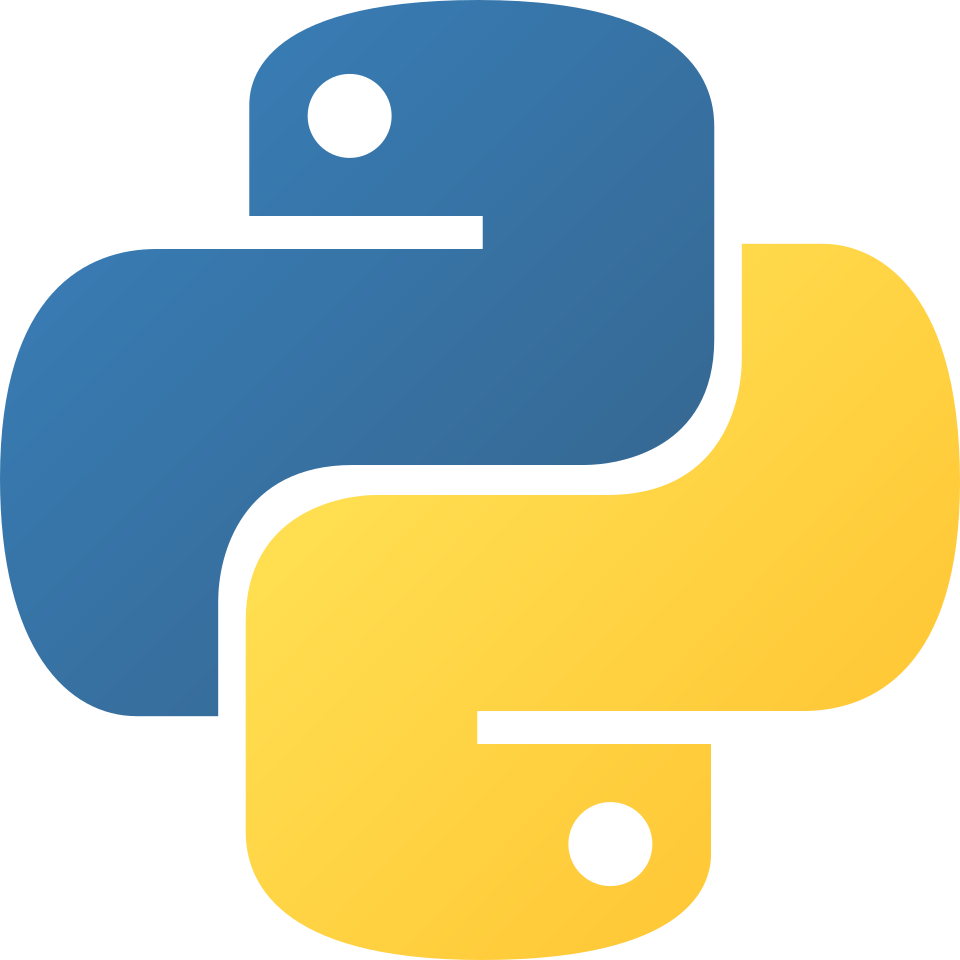

### ***PYSPARK APACHE***

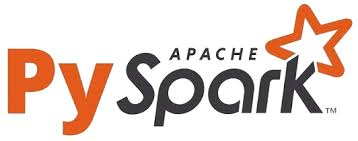

#### CREATING DELTA TABLES IN FABRIC

1. Load a a CSV content to a DF

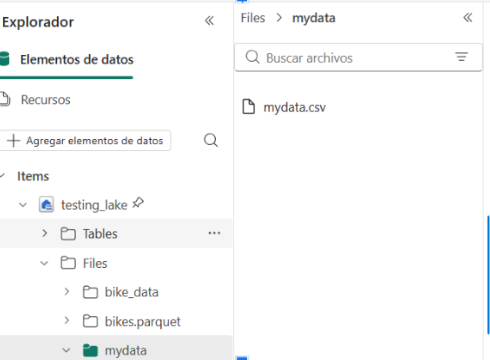



In [ ]:
df = spark.read.load('Files/mydata/mydata.csv', format = 'csv', header = True)
display(df)

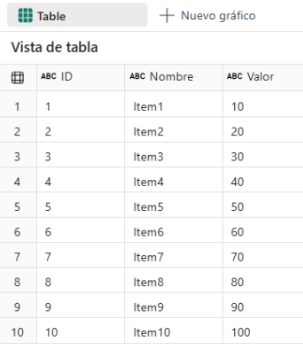

2. Save the df as a Delta Table

In [ ]:
df.write.format("delta").saveAsTable("mytable")

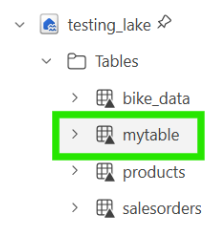

#####**Manage VS External Tables**

**Managed Tables:** Both the table definition in the metastore and the data files are managed by the spark enviroment. When the table is deleted, the associated files are also removed.

**External Tables:** The relational table definition points to a different storage location.

In the figure below, the table is created in the metastore, but parquet files and JSON logs are stored un the Files/directory.

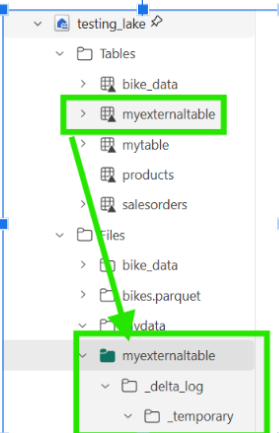

In [ ]:
df.write.format("delta").saveAsTable("bTabla", path = "Files/1_folder")

If the table is deleted, the files are still stored.

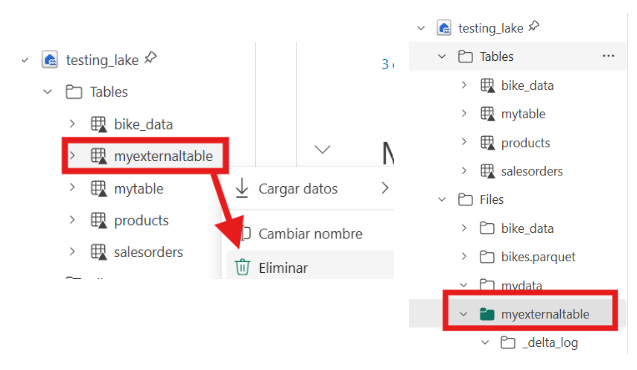

#### CREATION OF TABLE METADATA

Delta table builder API

In [ ]:
from delta.tables import *
DeltaRable.create(spark) \
  .tableName("deltabuildtable") \
  .addColumn("producto", "INT") \
  .addColumn("ProducName", "STRING") \
  .addColumn("Category", "STRING") \
  .addColumn("Price", "FLOAT")
  .execute()

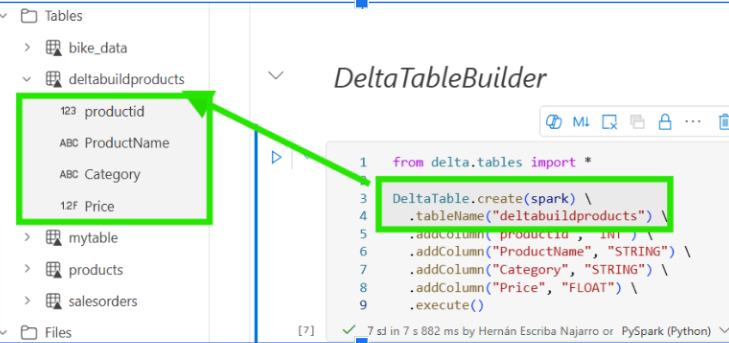

#### SAVE DATA IN DELTA FORMAT

Without create a table, it can be useful to save results or transformations made with Spark. It also possible to overwrite or append data.
Delta files are saved in Parquet format and it contains a delta log folder that contains transacctions.

In [ ]:
delta_path = "Files/onlydatatable"
df.write.format("delta").save(delta_path)

Es posible reemplazar y anexar nueva data de otros df

In [ ]:
new_df = df
new_df.write.format("delta").mode("overwrite").save(delta_path)
#Append
new_df.write.format("delta").mode("append").save(delta_path)

#### MODIFY DELTA TABLES API



In [ ]:
from delta.tables import *
from pyspar.sql.functions import *

#CREATE a DeltsTable object
delta_path = "abfss://..." #Delta table files path
deltaTable = DeltaTable.forPath(spark, delta_path)

#UPDATE data
deltaTable.update(
    condition = "Category == 'Accessories'",
    set = {"ListPrice": "ListPrice * 0.9"}
)

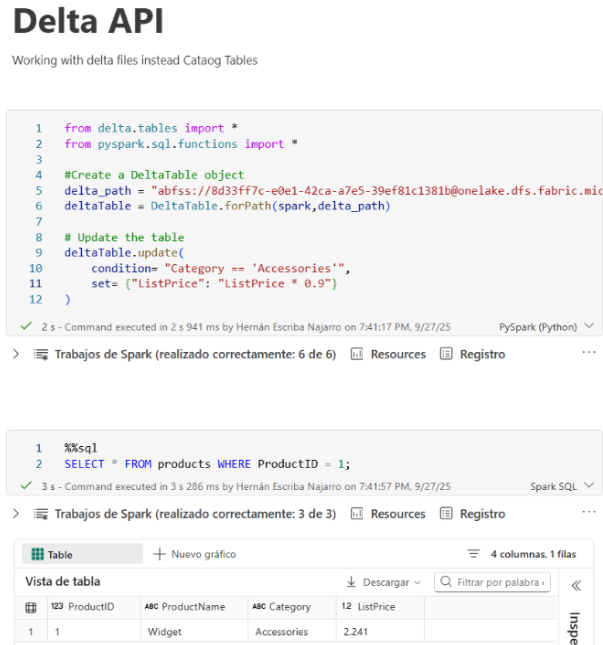

#### VACUUM COMMAND

Each time a transaction on a Delta table is completed successfully, the info is recorded in the **_delta_log** folder. Which keeps track of all commits made to the table, indicating which Parquet files are currently valid as well as mantainig different table versions.
Thus mechanism makes it possible to query or rerstore previous versions of the table and recover historical data. However it also generates a large number of files, which consume cosidareble storage space.


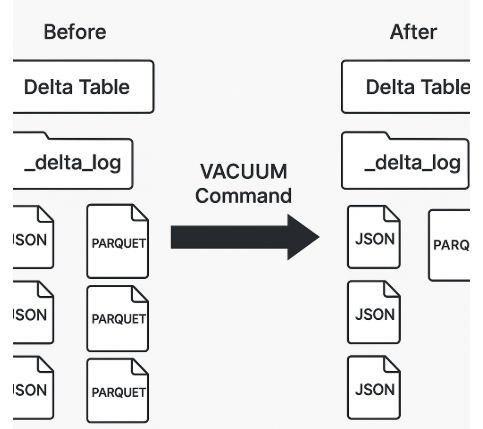

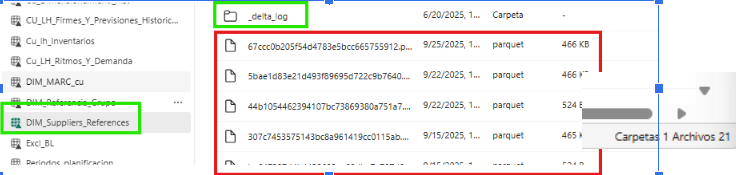

Delta log folder contains JSONs with the info of versions, it can see it with a notebook and SparkSQL

In [ ]:
%%sql
DESCRIBE HISTORY db_name.table_name

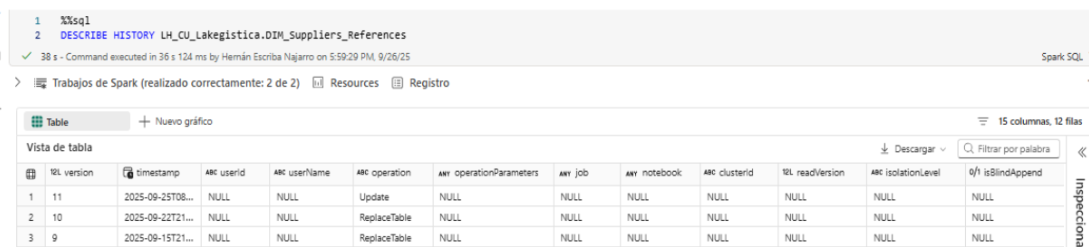

The Solution is delete old and unnecesary versuins of data, it sohould use: **VACUUM**

In [ ]:
%%sql
VACUUM db_name.table_name RETAIN 168 HOURS;

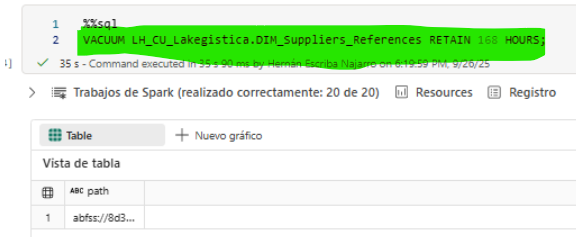

Also this operation is registered on the logs file: If it repeats the DESCRIBE HISTORY command:

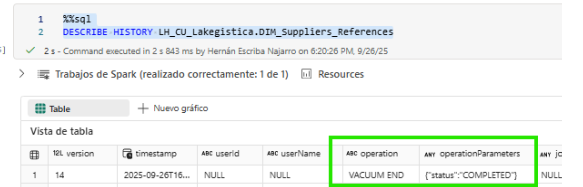

**RESULTS**

After VACUUM command is applied, the results are as follows:
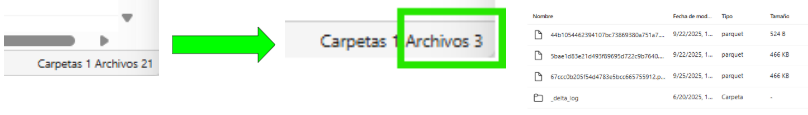

#### PARTITIONED TABLES

Delta lake allows you organize your data in partitions. Increase the performance. Partition by year, product type. Partitions storage in subfolders with the name of category. But the small partitions can destroy performance increasing problems with small files.

Use it if:
- High cuantity of data and the data can be divide in big parts.

Dont use if:
- Small volumes and high cardinality.

Granularity and how the data will be queried.

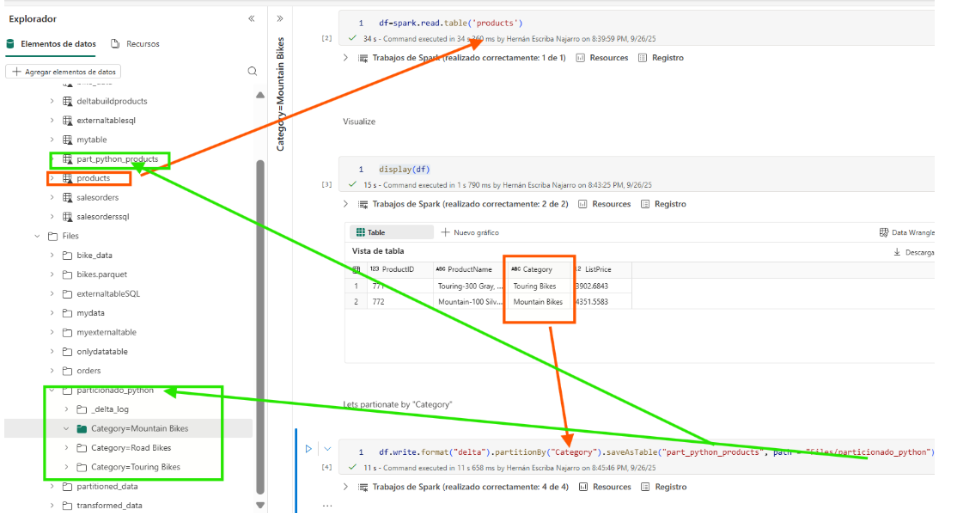


In [ ]:
df = spark.read.table('table_name')
display(df)
df.write.format("delta").partitionBy("Category").saveAsTable("partitioned_table", path = "Files/partitioned_files")


#### TIME TRAVELLING

In [ ]:
%%sql
DESCRIBE HISTORY table_name

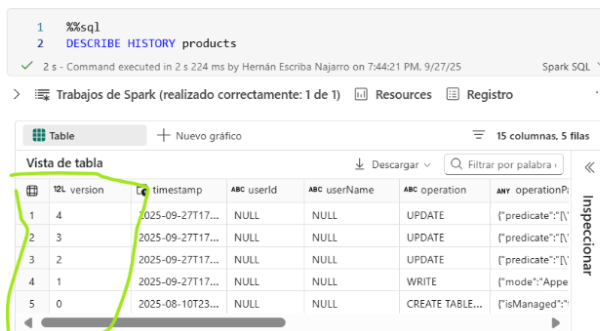

In [ ]:
df = spark.read.format("delta").option("versionAsOF",0).load(delta_path)
display(df.tail(5))
print(df.count())


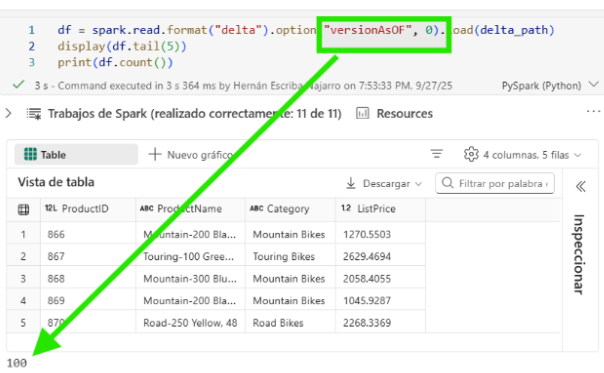

In [ ]:
df = spark.read.format("delta").option("versionAsOF",4).load(delta_path)
display(df.tail(5))
print(df.count())

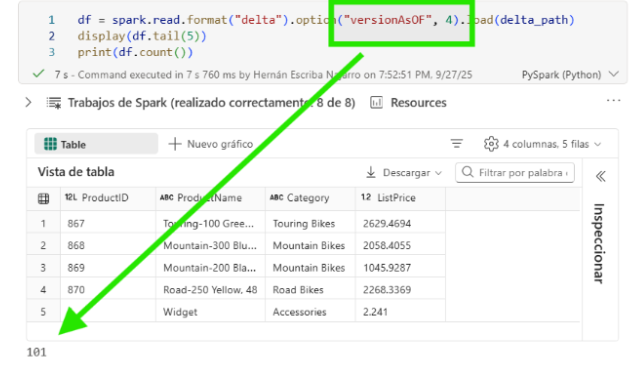

#### SPARK STRUCTURED STREAMING

**Load data in a df from a delta table**

In [ ]:
stream_df = spark.readStream.format("delta") \
        .option("ignoreChanges", "true") \
        .table("table_name")

In [ ]:
#Check if the streaming is on
stream_df.isStreaming

**Trasform stream_df**:

Filter all NULL values of columnn price and add columns isBike and Total

In [ ]:
from pyspark.sql.functions import col, expr
transformed_df = stream_df.filter(col("Price").isNotNull()) \
                .withColumn('IsBike', expr("INSTR(Product, 'Bike') > 0").cast('int')) \
                .withColumn('Total', expr("Quantity * Price").cast('decimal'))

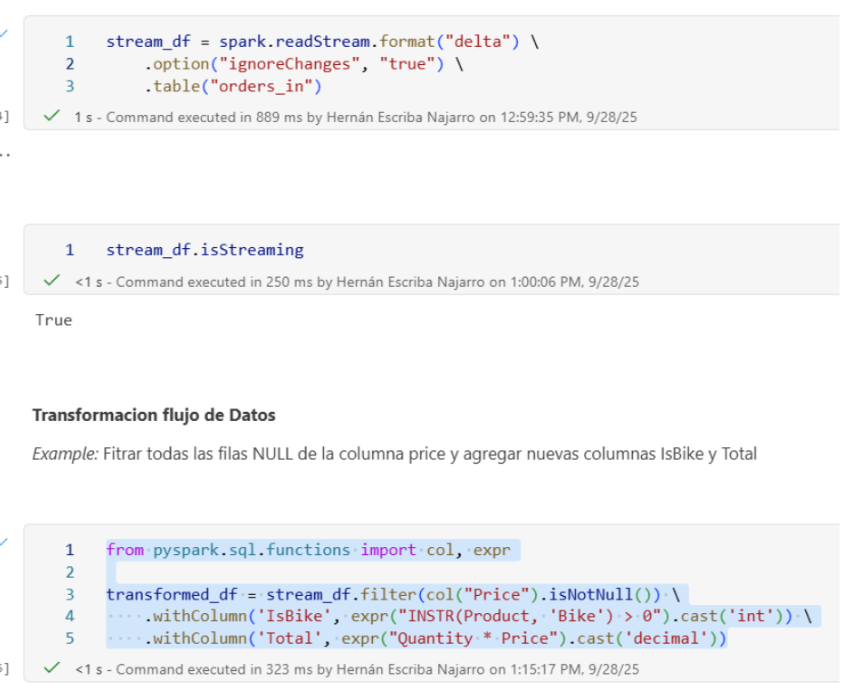

**Use a delta table as destination**

In [ ]:
output_table_path = 'Tables/orders_proccessed'
checkpointpath = 'Files/delta/checkpoint'
deltastream = transformed_df.writeStream.format("delta").option("checkpointLocation", checkpointpath)
print("Streaming to orders_processed")

In [ ]:
%%sql
-- Test if the data is arriving
SELECT *
FROM orders_proccessed
ORDER BY Order_id

**Stop the stream**

In [ ]:
deltastrean.stop()
deltastream.isActive

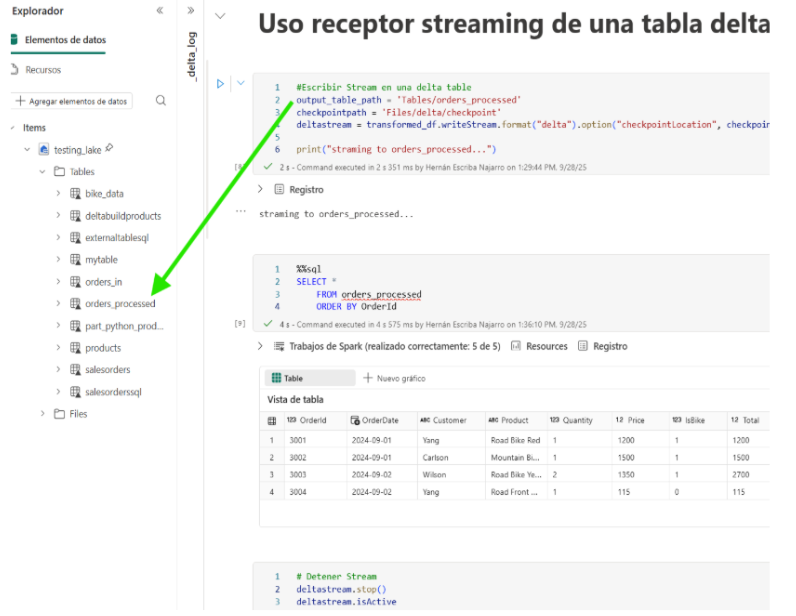

####TRANSFORM DATA NOTEBOOK

In [ ]:
# Set this cell as parameters cell
table_name = "sales"

In [ ]:
from pyspark.sql.functions import *

df = spark.read.format("csv").option("header","true").load("Files/new_data_folder/*.csv")

df = df.withColumn("Year", year(col("date_column"))).withColumn("month", month(col("date_column")))

df = df.withColumn("FirstName", split(col("CustomerName"), " ").getItem(0)).withColumn("LastName", split(col("CustomerName"), " ").getItem(1))

#Reorder and filter Columns
df = df["SalesOrderNumber", "Year", "Month", "FirstNmae", "LastName"]

df.write.format("delta").mode("append").saveAsTable(table_name)



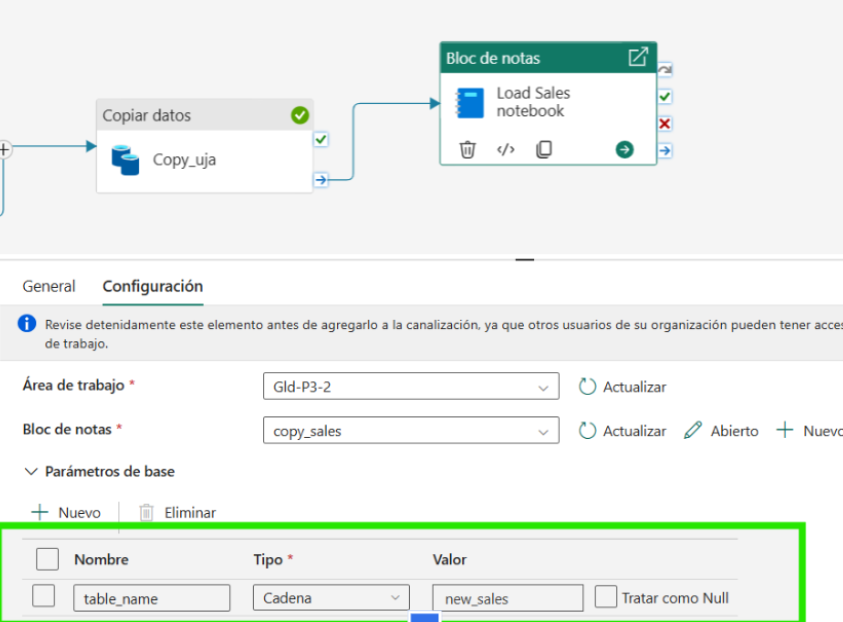

## **SQL**

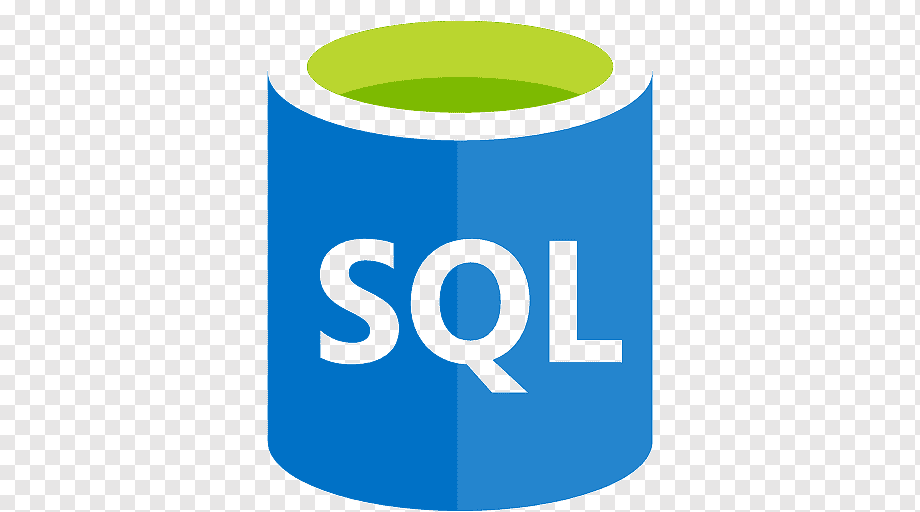

### **SPARKSQL**

#### CREATE A TABLE METADATA

In [ ]:
%%sql
CREATE TABLE salesordersSQL
(
  OrderId INT NOT NULL,
  OrderDate TIMESTAMP NOT NULL,
  CustomerName STRING,
  SalesTotal FLOAT NOT NULL
)
USING DELTA

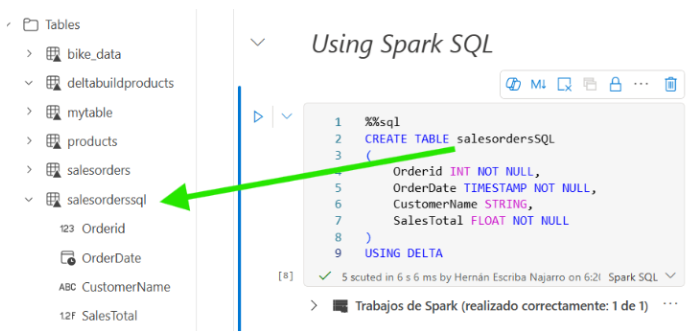

Also possible to crate an external Table

In [ ]:
%%sql
CREATE TABLE externaltableSQL
USING DELTA
LOCATION 'Files/externaltableSQLfiles'

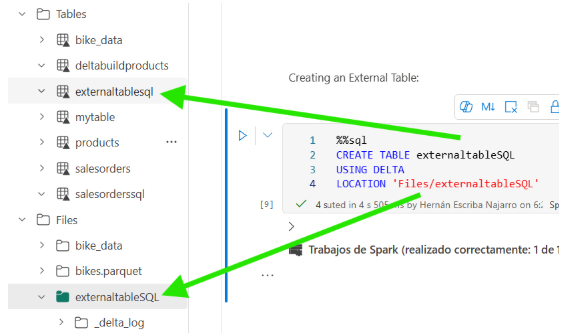

#### MODIFICACION DE DATOS

In [ ]:
spark.sql("INSERT INTO table_name VALUES (1, 'A', 'B', 1.6)")

In [ ]:
%%sql
UPDATE table_name
SET column_name = 1.5 WHERE item_id_column = 1;

In [ ]:
%%sql
SELECT * FROM table_name WHERE item_id_colum = 1;

In [ ]:
var = spark.sql("SELECT * FROM table_name WHERE id_item = 1")
display(var)

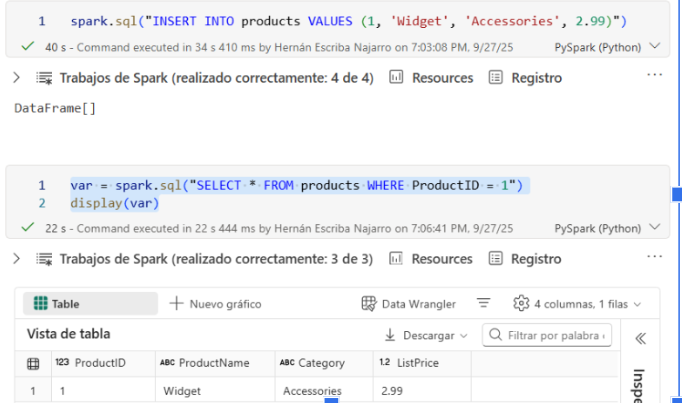

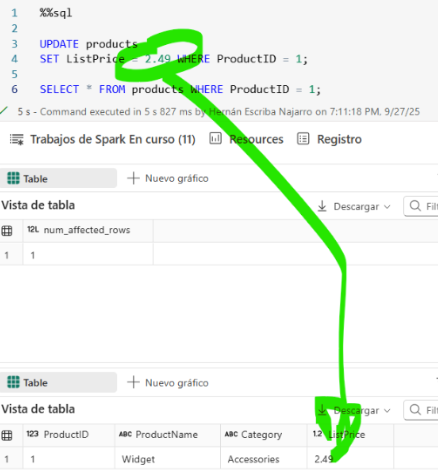

### SQL DATAWAREHOUSE

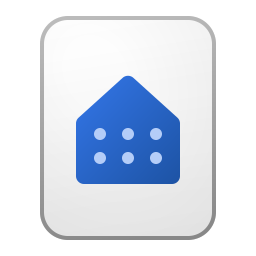



#### INGEST DATA FROM CSV

In [ ]:
%%sql
COPY INTO dbo.table_name
FROM 'https://....' WITH (
  FILE_TYPE = 'CSV'
  , CREDENTIAL = (
    IDENTITY = 'Shared Access Signature'
    , SECRET = 'xxx'
  )
  , FIRST_ROW = 2
)
GO


#### CREATION OF TABLES AND INSERTIONS

[Code TSQL to practice with DIMS AND FACT tables](https://raw.githubusercontent.com/MicrosoftLearning/dp-data/main/create-dw.txt)

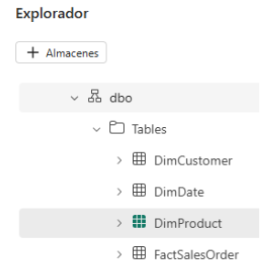

In [ ]:
%%sql
CREATE TABLE dbo.table_name
(
  id_item_key INTEGER NOT NULL,
  product_alt_key VARCHAR(25) NULL,
  ProductName VARCHAR(50) NOT NULL,
  ListPrice DECIMAL(5,2) NULL
);
GO

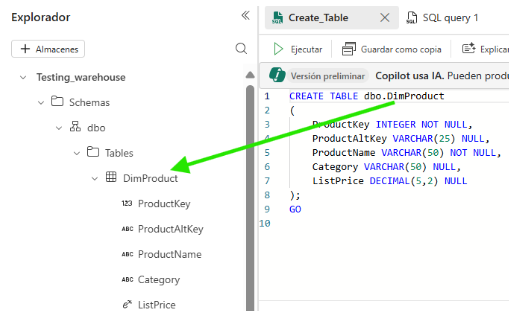

In [ ]:
%%sql
INSERT INTO dbo.table_name
VALUES
(1,'RING1', 'Bycycle bell',5.99),
(2,'RING2', 'Bycycle bell',6.99),
(3,'RING3', 'Bycycle bell',7.99);
GO


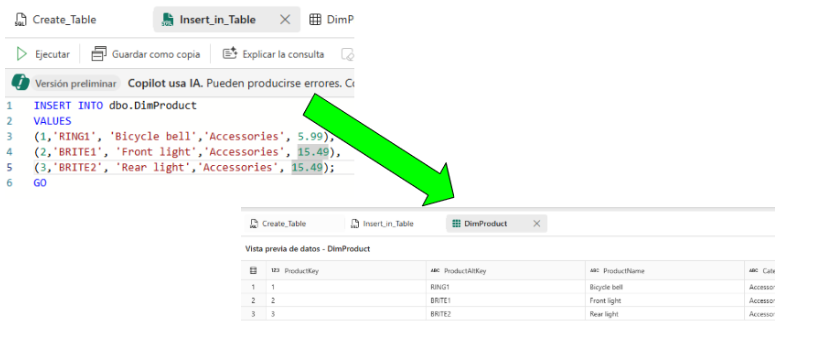

#### JOINS, GROUP BY AND ORDER BY QUERIES

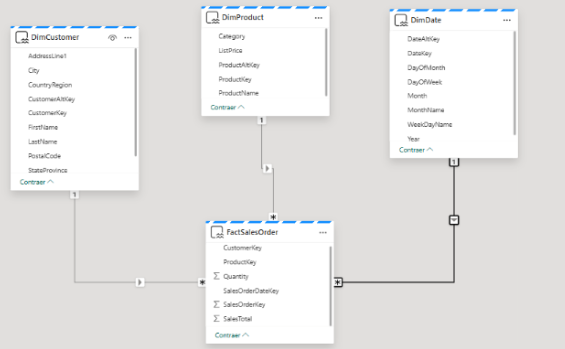

In [ ]:
%%sql
SELECT d.[Year] AS CalendarYear,
       d.[Month] AS MonthOfYear,
       d.MonthName AS MonthName
       SUM(so.SalesTotal) AS SalesRevenue
FROM FactSalesOrder AS so
JOIN DimDate AS d
  ON so.SalesOrderDateKey = d.DateKey
GROUP BY d.[Year], d.[Month], d.MonthName
ORDER BY CalendarYear, MonthOfYear;


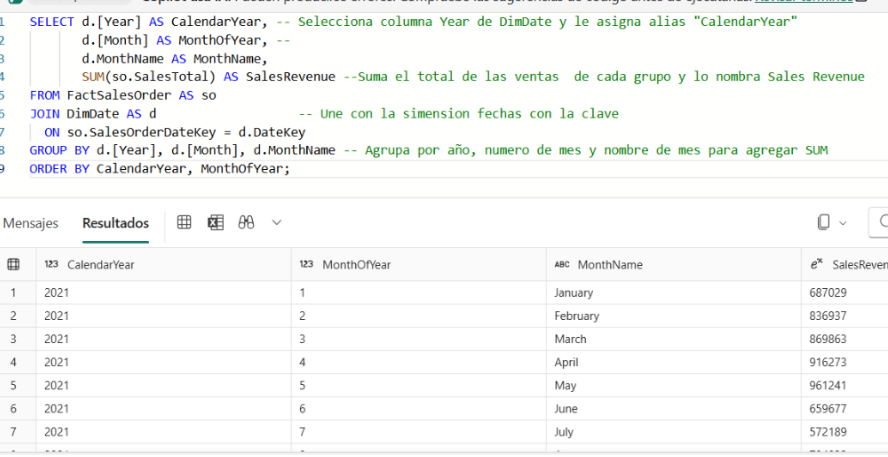

In [ ]:
%%sql
SELECT d.[Year] AS CalendarYear,
       d.[Month] AS MonthOfYear,
       d.MonthName AS MonthName,
       c.CountryRegion AS SalesRegion
       SUM(so.SalesTotal) AS SalesRevenue
FROM FactSalesOrder AS so
JOIN DimDate AS d
  ON so.SalesOrderDateKey = d.DateKey
JOIN DimCustomer AS c
  ON so.CustomerKey = c.CustomerKey
GROUP BY d.[Year], d.[Month], d.MonthName, c.CountryRegion
ORDER BY CalendarYear, MonthOfYear, SalesRegion;

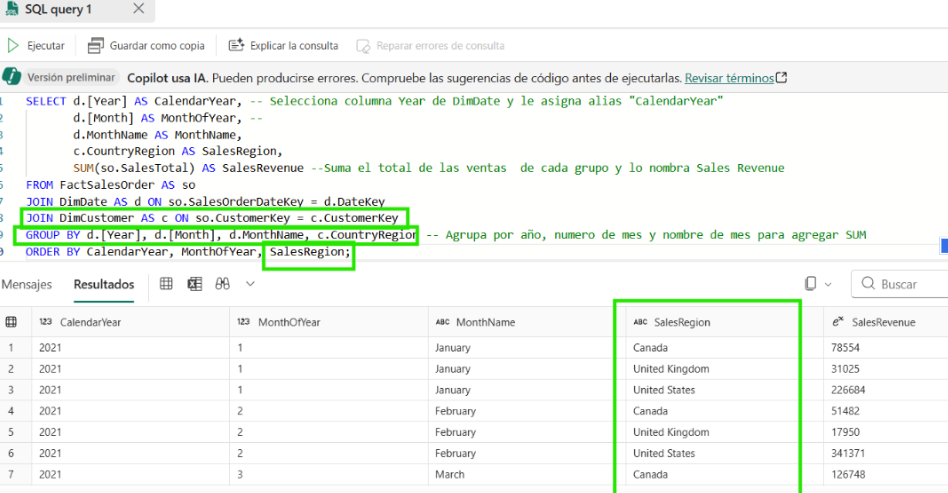

#### SQL VIEWS


In [ ]:
%%sql
CREATE OR ALTER VIEW dbo.view_name
AS
SELECT d.[Year] AS CalendarYear,
       d.[Month] AS MonthOfYear,
       d.MonthName AS MonthName,
       c.CountryRegion AS SalesRegion
       SUM(so.SalesTotal) AS SalesRevenue
FROM FactSalesOrder AS so
JOIN DimDate AS d
  ON so.SalesOrderDateKey = d.DateKey
JOIN DimCustomer AS c
  ON so.CustomerKey = c.CustomerKey
GROUP BY d.[Year], d.[Month], d.MonthName, c.CountryRegion;

In [ ]:
%%sql
SELECT CalendarYear, MonthName, SalesRegion, SalesRevenue
FROM dbo.view_name
ORDER BY CalendarYear, MonthName, SalesRegion

#### MONITOR A SQL DATAWAREHOUSE

Dinamic Manage Views: To monitor Current status:

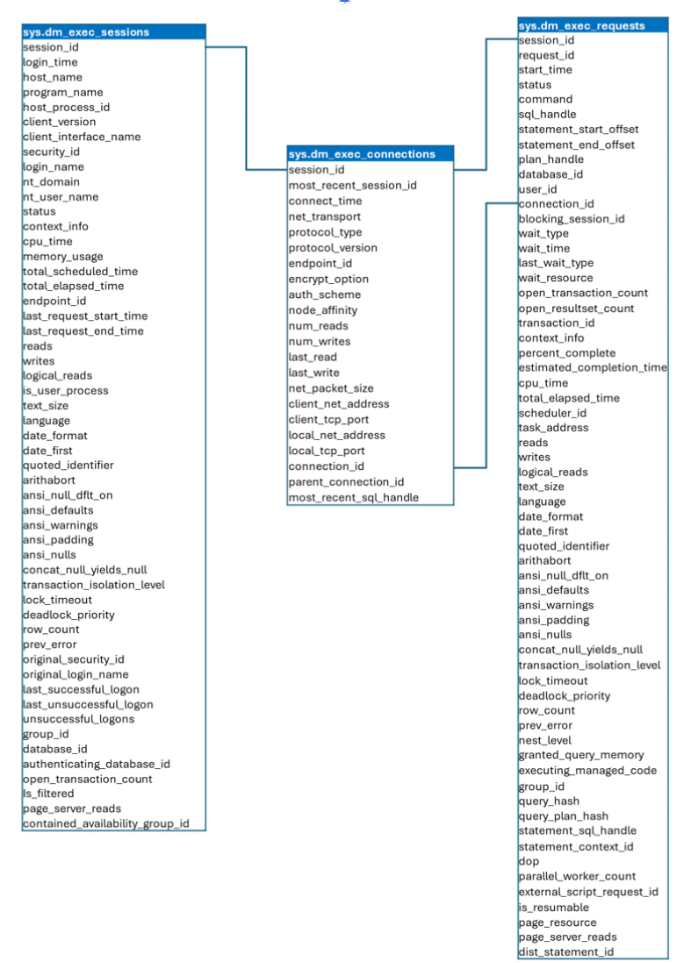




*   **sys.dm_exec_connections:** Returns info about connections.
*   **sys.dm_exec_sessions:** Info about authenticated sessions.

*   **sys.dm_exec_requests:** Info about active requests.



In [ ]:
%%sql
SELECT sessions.session_id, sessions.login_name, connections.client_net_address,
      requests.command, requests.start_time, requests.total_elapsed_time
FROM sys.dm_exec_connections AS connections
INNER JOIN sys.dm_exec_sessions AS sessions
  ON connections.session_id = sessions.session_id
INNER JOIN sys.dm_exec_requests AS requests
  ON requests.session_id = sessions.session_id
WHERE requests.status  = 'running'
  AND requests.database_id = DB_ID()
ORDER BY requests.total_elapsed_time

PAST EXECUTIONS

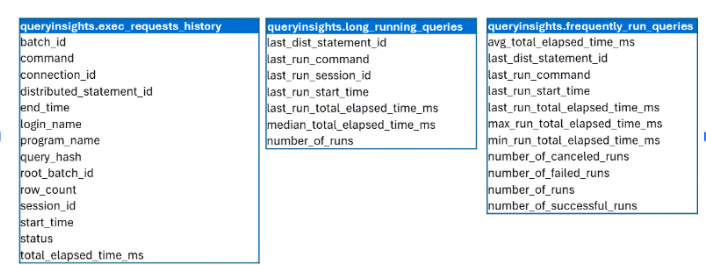

*   queryinsights.**exec_requests_history**: Details about each completed SQL query.
*   queryinsights.**long_running_queries**: Details about time running queries
* queryinsights.**frequently_run_queries**: Details about frequently running queries



In [ ]:
%%sql
-- Consultas de hace una hora
SELECT start_time, login_name, command
FROM queryinsights.exec_requests_history
WHERE start_time > DATE_ADD(MINUTE, -60, GETUTCDATETIME())

In [ ]:
%%sql
-- Consultas mas largas ejecutadas mas de una vez
SELECT last_run_command, number_of_runs,
median_total_elapsed_time_ms, last_run_start_time
FROM queryinsights.long_running_queries
WHERE number_of_runs > 1
ORDER BY median_total_elapsed_time_ms DESC;


In [ ]:
%%sql
-- Comandos de ejecucion frecuente
SELECT last_run_command, number_of_runs, number_of_successful_runs,
  number_of_failed_runs
FROM queryinsights.frequently_run_queries
ORDER BY number_of_runs DESC

## **KQL**

#### KQL QUERIES

Take just 100 rows:



```
TaxiTrips
| take 100
```

Summarize counting values:

```
TaxiTrips
| summarize trip_count = count() by taxi_id
```





Query code that take 10 rows of 3 columns where the fare_amount is bigger than 20



```
TaxiTrips
| where fare_amount > 20
| project trip_id, pickup_datetime, fare_amount
| take 10
```




The next code queries stock tables from five minutes ago and calutaes average groping by symbol and displaying column sybol and avgPrice calculated column.
```
stock
| where ["time"] > ago(5m)
| summarize avgPrice = avg(todouble(bidPrice)) by symbol
| project symbol, avgPrice
```



**INCREASE PERFORMANCE IN KQL QUERIES**

In fuction of quantity of data processed, query first command which filter more data. Select 3 columns instead 50.

**Time Filtering**


```
TaxiTrips
| where pickup_datetime > ago(30min) // Filter first uses time index
| project trip_id, pickup_datetime, fare_amount
| summarize avg_fare = avg(fare_amount) by vendor_id
```

**Where condition**


```
TaxiTrips
| where pickup_datetime > ago(1d) //Time filter first
| where vendor_id == "VTS" // Specific vendor
| where fare_amount > 0
| summarize trip_count = count()
```
**Reduce number of columns**


```
TaxiTrips
| project trip_id, pickup_datetime, fare_amount
| where pickup_datetime > ago(1d)
| summarize avg_fare = avg(fare_amount)
```







**Optimization of agregations and joins**

**Limit results while explore data**


```
TaxiTrips
| where pickup_datetime > ago(1d)
| summarize trip_count = count() by trip_id, vendor_id
| limit 1000 // Limit results for exploration
```
**Set small table first**
```
VendorInfo
| join kind = inner TaxiTrips on vendor_id

TaxiTrips
| join kind = inner VendorInfo on vendor_id
```




#### **Materialized View**

Create one materialized view:

```
.create materialized-view TripsByVendor on table TaxiTrips
{
  TaxiTrips
  | summarize trips = count(), avg_fare = avg(fare_amount), total_revenue = sum(fare_amount)
  by vendor_id, pickup_dare = format_datetime(picup_datetime, "yyyy.-MM-dd")
}
```

Query a materiliazed view


```
TripsByVendor
| where pickup_date >= ago(7d)
| project pickup_date, vendor_id, trips, avg_fare, total_revenue
| sort by pickup_date desc, total revenue desc
```



#### **Stored functions**

Create a stored function:

```
.create-or-alter function trips_by_min_passenger_count(num_passengers:long)
{
  TaxiTrips
  | where passenger_count >= num_passengers
  | project trip_id, pickup_datetime
}
```

Call a stored function:


```
trips_by_min_passenger_count(3)
| take 10
```

